## Imports

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
reviews_preprocessed = pd.read_csv("../data/processed/reviews_preprocessed.csv", index_col=0)

In [24]:
reviews_preprocessed.isna().sum()

ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
Sentiment                 0
Text_clean                1
dtype: int64

In [25]:
reviews_preprocessed = reviews_preprocessed.dropna(subset=["Text_clean"])

### Train/test split

Using an 80/20 stratified split to preserve the class balance (positive/negative ratio) in
both sets, given the class imbalance observed during EDA.

In [26]:
X = reviews_preprocessed["Text_clean"]
y = reviews_preprocessed["Sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### TF-IDF vectorization

Converting cleaned text into numerical features using TF-IDF, limited to the 5000 most
frequent terms. The vectorizer is fit only on training data (`fit_transform`) and then
applied to test data (`transform`) to avoid data leakage — computing IDF weights using
test data would let information from the test set leak into training.

In [27]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Baseline model: Logistic Regression

Using Logistic Regression as a simple, interpretable baseline — consistent with the approach
used in credit-risk-analysis. `max_iter=1000` ensures convergence given the 5000-dimensional
TF-IDF feature space.

In [28]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.67      0.74     16393
           1       0.94      0.97      0.96     88709

    accuracy                           0.93    105102
   macro avg       0.89      0.82      0.85    105102
weighted avg       0.92      0.93      0.92    105102



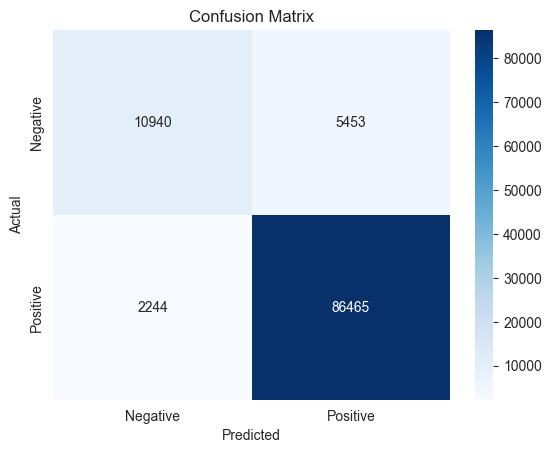

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Baseline model results

Logistic Regression on TF-IDF features (max_features=5000), trained on 80/20 stratified split:

- **Positive class**: precision 0.94, recall 0.97, F1 0.96
- **Negative class**: precision 0.83, recall 0.67, F1 0.74
- **Macro avg F1**: 0.85, **Accuracy**: 0.93

Accuracy is inflated by class imbalance in the test set (88,709 positive vs 16,393 negative) —
a naive "always predict positive" baseline would already score ~84% accuracy. Macro avg F1 is
a more honest metric here, weighting both classes equally.

The model struggles more with the negative class, missing ~33% of actual negative reviews
(recall 0.67) — likely because negative reviews are the minority class. This is the main area
to address in the next notebook, through techniques like class weighting.